## GUINEAINS STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

guineains=pd.read_csv('../stock_data/guineains.csv') ## so it can be small letter. This is cool.
guineains=guineains.drop(columns=['high_price','low_price'])
guineains.rename(columns={'trade_date':'date'},inplace=True)
guineains['date']=pd.to_datetime(guineains['date'])
guineains['month']=guineains['date'].dt.month
guineains['quarter']=guineains['date'].dt.quarter
guineains['year']=guineains['date'].dt.year

guineains

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42814,GUINEAINS,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43374,GUINEAINS,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43484,GUINEAINS,2017-01-05,0.50,0.50,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43594,GUINEAINS,2017-01-06,0.50,0.50,49850,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43684,GUINEAINS,2017-01-09,0.50,0.50,165000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2256,298068,GUINEAINS,2026-07-13,0.90,0.90,5552337,2026-07-13T15:10:02.995074+00:00,7,3,2026
2257,298506,GUINEAINS,2026-07-14,0.90,0.90,5502640,2026-07-14T15:10:03.094441+00:00,7,3,2026
2258,298944,GUINEAINS,2026-07-15,0.93,0.93,2229968,2026-07-15T15:10:03.078609+00:00,7,3,2026
2259,299382,GUINEAINS,2026-07-16,0.88,0.88,7494167,2026-07-16T15:10:03.113936+00:00,7,3,2026


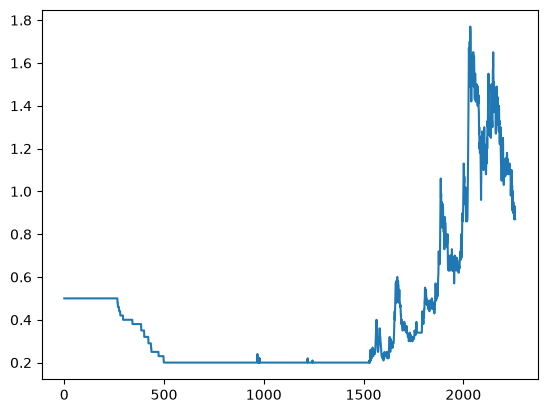

In [2]:
import matplotlib.pyplot as plt

plt.plot(guineains['close_price'])
plt.show()

In [3]:
guineains_end_month_df = (
    guineains
    .sort_values("date")
    .groupby(guineains["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

guineains_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45384,GUINEAINS,2017-01-31,0.50,0.50,39000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47206,GUINEAINS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49322,GUINEAINS,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51150,GUINEAINS,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53072,GUINEAINS,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35306,GUINEAINS,2026-03-31,1.18,1.18,2283173,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281132,GUINEAINS,2026-04-30,1.15,1.15,2969565,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284198,GUINEAINS,2026-05-29,1.09,1.09,577084,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294126,GUINEAINS,2026-06-30,0.91,0.91,2418866,2026-06-30T15:10:03.08168+00:00,6,2,2026


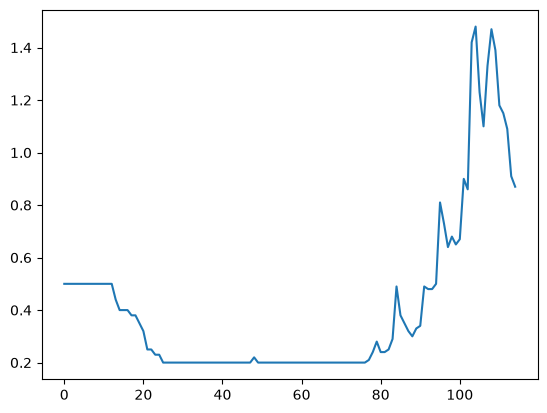

In [4]:
plt.plot(guineains_end_month_df['close_price'])
plt.show()

In [5]:
guineains_end_month_df['returns']=guineains_end_month_df['close_price'].pct_change()*100
guineains_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45384,GUINEAINS,2017-01-31,0.50,0.50,39000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47206,GUINEAINS,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49322,GUINEAINS,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51150,GUINEAINS,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53072,GUINEAINS,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35306,GUINEAINS,2026-03-31,1.18,1.18,2283173,2026-03-31T15:00:02.085058+00:00,3,1,2026,-15.107914
111,281132,GUINEAINS,2026-04-30,1.15,1.15,2969565,2026-04-30T15:00:02.170664+00:00,4,2,2026,-2.542373
112,284198,GUINEAINS,2026-05-29,1.09,1.09,577084,2026-05-29T15:00:02.455558+00:00,5,2,2026,-5.217391
113,294126,GUINEAINS,2026-06-30,0.91,0.91,2418866,2026-06-30T15:10:03.08168+00:00,6,2,2026,-16.513761


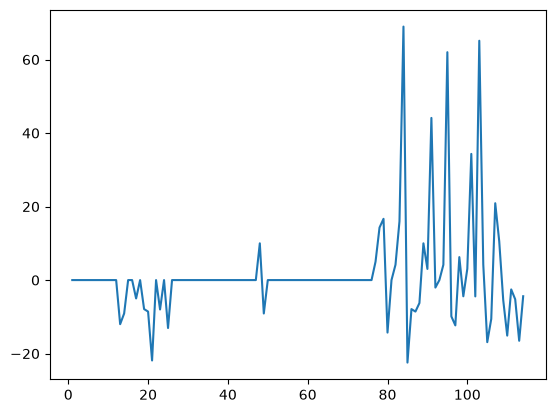

In [6]:
plt.plot(guineains_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(guineains_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.512675982084268), np.float64(1.0149389840308244e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(819.8021408416521))
stationary


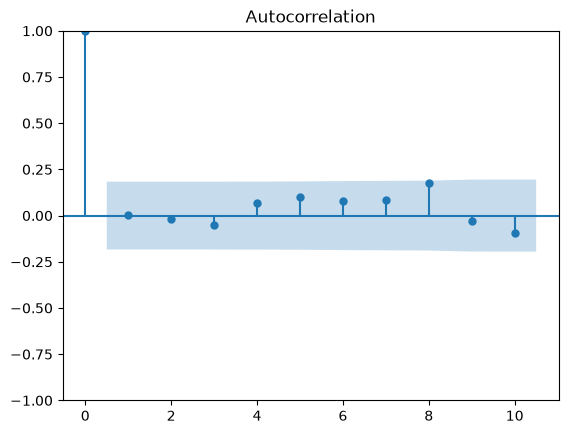

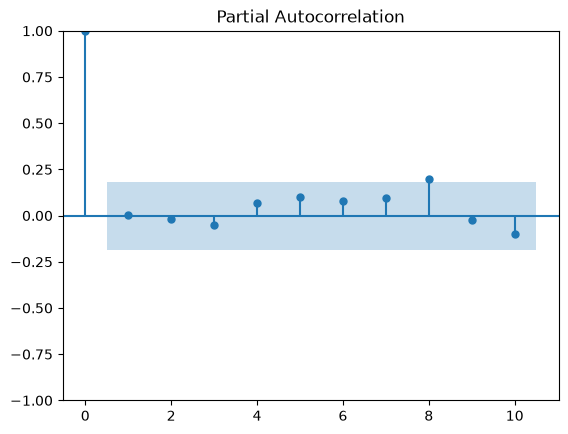

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(guineains_end_month_df['returns'].dropna(), lags=10)
plot_pacf(guineains_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=guineains_end_month_df['close_price'][:-10]
test=guineains_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -40.764007597340935]
[0, 0, 0, 0, 0, 1, -17.7954503272636]
[0, 0, 0, 0, 0, 2, -8.855847979402956]
[0, 0, 0, 0, 1, 0, -7.842592592592595]
[0, 0, 0, 0, 1, 1, -5.341266784750125]
[0, 0, 0, 0, 1, 2, -4.1391018116919245]
[0, 0, 0, 0, 2, 0, -3.4714506192586576]
[0, 0, 0, 0, 2, 1, -4.127394843138528]
[0, 0, 0, 0, 2, 2, -4.095132105869575]
[0, 0, 0, 1, 0, 0, -9.036498249396226]
[0, 0, 0, 1, 0, 1, -6.016532467972875]
[0, 0, 0, 1, 0, 2, -5.239310491423589]
[0, 0, 0, 1, 1, 0, -3.800254354932152]
[0, 0, 0, 1, 1, 1, -4.118756713426635]
[0, 0, 0, 1, 1, 2, -3.8591850614958023]
[0, 0, 0, 1, 2, 0, -4.107830414163384]
[0, 0, 0, 1, 2, 1, -3.4366559368359892]
[0, 0, 0, 1, 2, 2, -4.052807273077889]
[0, 0, 0, 2, 0, 0, -4.933060879326793]
[0, 0, 0, 2, 0, 1, -5.1110490308590295]
[0, 0, 0, 2, 0, 2, -4.980849991852703]
[0, 0, 0, 2, 1, 0, -3.927072008727171]
[0, 0, 0, 2, 1, 1, -4.036012640249451]
[0, 0, 0, 2, 1, 2, -3.8924173659136905]
[0, 0, 0, 2, 2, 0, -4.071380047964234]
[0, 0, 0, 2, 2, 1, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
405,1,2,0,0,0,0,-134.582728
414,1,2,0,1,0,0,-123.824910
424,1,2,0,2,0,1,-123.211273
423,1,2,0,2,0,0,-123.078738
416,1,2,0,1,0,2,-122.731117
...,...,...,...,...,...,...,...
62,0,0,2,0,2,2,-2.421615
486,2,0,0,0,0,0,-2.325185
243,1,0,0,0,0,0,-2.324218
270,1,0,1,0,0,0,-2.322327


Highly poor. We move to returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=guineains_end_month_df['returns'].dropna()[:-10]
test=guineains_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.15462560653880209]
[0, 0, 0, 0, 0, 1, -0.7188083901866027]
[0, 0, 0, 0, 0, 2, -0.46391219403489314]
[0, 0, 0, 0, 1, 0, -3.3568283190496793]
[0, 0, 0, 0, 1, 1, -1.033925650078087]
[0, 0, 0, 0, 1, 2, -1.1791237281310396]
[0, 0, 0, 0, 2, 0, -18.0578263099468]
[0, 0, 0, 0, 2, 1, -4.418734050116057]
[0, 0, 0, 0, 2, 2, -2.7426613709481984]
[0, 0, 0, 1, 0, 0, -0.4490514877499776]
[0, 0, 0, 1, 0, 1, -0.323535304602397]
[0, 0, 0, 1, 0, 2, -0.3276019187539094]
[0, 0, 0, 1, 1, 0, -1.3647564535803762]
[0, 0, 0, 1, 1, 1, -1.054084421496119]
[0, 0, 0, 1, 1, 2, -1.0555652317168698]
[0, 0, 0, 1, 2, 0, -6.274498582253969]
[0, 0, 0, 1, 2, 1, -2.901956165350344]
[0, 0, 0, 1, 2, 2, -2.893810655565353]
[0, 0, 0, 2, 0, 0, -0.32617968948185294]
[0, 0, 0, 2, 0, 1, -0.32499845861384746]
[0, 0, 0, 2, 0, 2, -1.1330064767489882]
[0, 0, 0, 2, 1, 0, -0.9199553819567841]
[0, 0, 0, 2, 1, 1, -1.0344596907660248]
[0, 0, 0, 2, 1, 2, -1.130013290611522]
[0, 0, 0, 2, 2, 0, -4.1413778475529535]
[0, 0,

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
537,2,0,1,2,2,0,-180506.176091
162,0,2,0,0,0,0,-1029.539063
163,0,2,0,0,0,1,-810.289106
171,0,2,0,1,0,0,-768.928766
182,0,2,0,2,0,2,-723.668507
...,...,...,...,...,...,...,...
10,0,0,0,1,0,1,-0.323535
270,1,0,1,0,0,0,-0.172025
0,0,0,0,0,0,0,-0.154626
27,0,0,1,0,0,0,-0.153921


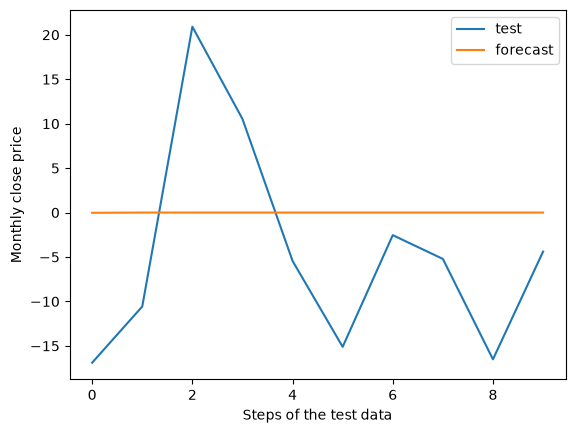

r2_score:  -0.15388580199570057
rmse:  12.35974440010774
description:  count    114.000000
mean       1.219576
std       13.552890
min      -22.448980
25%        0.000000
50%        0.000000
75%        0.000000
max       68.965517
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=guineains_end_month_df['returns'].dropna()[:-10]
y_test=guineains_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', guineains_end_month_df.returns.dropna().describe())

Very horrible. We have to visit again
